# SlouchFix -- Posture Pipeline Ablation Study

Self-contained notebook (upload as-is to Kaggle or Colab). Downloads its
own copy of the `good` / `slouched` subset of
`SeiyaCM/KandenAiHackathonPosture2` and runs a staged ablation:

1. **Pose Estimator** (6 arms) -- MediaPipe Pose, MoveNet, RTMPose,
   ViTPose-S, HRNet-W32, YOLO-Pose. (OpenPose was dropped: it only runs
   on CPU via `cv2.dnn` regardless of a GPU runtime -- measured at
   ~2.1s/image, it would dominate the notebook's total runtime for a
   single arm that is unlikely to win on the latency half of the
   selection rule anyway.)
2. **Keypoint Representation** (5 arms) -- raw 2D, normalized, relative,
   bone vectors, angles
3. **Feature Selection** (2 arms) -- all features vs. PCA (95% variance)
4. **Posture Classifier** (4 arms) -- SVM, XGBoost, LightGBM, 1D CNN

Baseline (arm 1 of every category) = MediaPipe Pose + raw 2D + all
features + SVM. Each stage holds every other category at its
already-decided winner and only varies the one being tested. The winner
of a stage is picked with `pick_best`: shortlist arms within
`ACCURACY_TOLERANCE_PP` percentage points of the top accuracy, then take
the lowest-latency arm in that shortlist -- because this feeds a
real-time webcam app, raw accuracy alone is the wrong objective.

Any pose backend that fails to install/run in the current environment is
skipped with a logged reason rather than crashing the notebook.

## Install

Pinned versions below aren't arbitrary -- they were hit and fixed while
developing this notebook, and installing them upfront saves Kaggle/Colab
from rediscovering the same failures:
- `tensorflow_hub` (MoveNet) imports `pkg_resources`, which recent
  `setuptools` (>=81) no longer ships -- but `setuptools==75.6.0` still
  has it AND already dropped the Python-3.12-incompatible
  `pkgutil.ImpImporter` reference that crashes even older setuptools.
- `ultralytics`/`huggingface_hub` need `filelock>=3.16.1` for `AsyncFileLock`.
- `openmim`/`mmcv` (attempted for HRNet-W32) crash outright on Python
  3.12 for the same `pkgutil.ImpImporter` reason; not worked around here,
  see the HRNet-W32 cell -- it's expected to report FAILED.

In [33]:
%pip install -q "setuptools==75.6.0" "filelock>=3.16.1"
%pip install -q mediapipe ultralytics tensorflow tensorflow-hub rtmlib transformers onnxruntime torch xgboost lightgbm scikit-learn requests pillow pandas matplotlib seaborn adjustText onnxmltools skl2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 22.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
openxlab 0.1.3 requires filelock~=3.14.0, but you have filelock 4.0.1 which is incompatible.
openxlab 0.1.3 requires rich~=13.4.2, but you have rich 15.0.0 which is incompatible.
openxlab 0.1.3 requires setuptools~=60.2.0, but you have setuptools 75.6.0 which is incompatible.
bigframes 2.48.0 requires rich<14,>=12.4.4, but you have rich 15.0.0 which is incompatible.


In [34]:
import io
import json
import math
import platform
import time
import warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import requests

warnings.filterwarnings("ignore")

## Config

`SAMPLE_PER_CLASS` is small here for a fast local smoke test. Set it to
1000 for the real run on Kaggle/Colab.

In [35]:
SAMPLE_PER_CLASS = 1000          # local smoke test; use 1000 for the real run
RANDOM_SEED = 42
ACCURACY_TOLERANCE_PP = 2.0    # "best balance" shortlist width, in percentage points
TRAIN_FRAC, VAL_FRAC = 0.7, 0.15  # remainder is test

HF_DATASET = "SeiyaCM/KandenAiHackathonPosture2"
ROWS_API = "https://datasets-server.huggingface.co/rows"
# Row ranges confirmed (by direct probing) to sit safely inside each
# label's contiguous block -- see scripts/download_hf_posture_subset.py.
LABEL_START_OFFSETS = {"good": ("01_good", 0), "slouched": ("02_slouch", 15000)}

rng = np.random.default_rng(RANDOM_SEED)

print(f"Python {platform.python_version()} on {platform.system()}")
print(f"Sample size: {SAMPLE_PER_CLASS} images/class")

Python 3.13.15 on Linux
Sample size: 1000 images/class


## Dataset download

Reuses the row-range trick from `scripts/download_hf_posture_subset.py`:
the dataset's rows are stored in contiguous per-label blocks, so a public
datasets-server API call can fetch exactly the rows we need instead of
the full ~52,500-image dataset.

In [36]:
def fetch_rows(offset: int, length: int, retries: int = 5) -> list[dict]:
    params = {"dataset": HF_DATASET, "config": "default", "split": "train", "offset": offset, "length": length}
    for attempt in range(retries):
        resp = requests.get(ROWS_API, params=params, timeout=30)
        if resp.status_code == 200:
            return resp.json()["rows"]
        if resp.status_code == 429:
            time.sleep(2 * (attempt + 1))
            continue
        resp.raise_for_status()
    raise RuntimeError(f"Failed to fetch rows at offset {offset}")


def download_image(url: str, retries: int = 5) -> "np.ndarray":
    from PIL import Image

    for attempt in range(retries):
        resp = requests.get(url, timeout=30)
        if resp.status_code == 200:
            return np.array(Image.open(io.BytesIO(resp.content)).convert("RGB"))
        if resp.status_code == 429:
            time.sleep(2 * (attempt + 1))
            continue
        resp.raise_for_status()
    raise RuntimeError(f"Failed to download {url}")


def load_dataset(n_per_class: int) -> tuple[list[np.ndarray], np.ndarray]:
    images: list[np.ndarray] = []
    labels: list[int] = []
    for class_name, (hf_label, start_offset) in LABEL_START_OFFSETS.items():
        y = 0 if class_name == "good" else 1
        fetched = 0
        offset = start_offset
        while fetched < n_per_class:
            length = min(100, n_per_class - fetched)
            rows = fetch_rows(offset, length)
            for entry in rows:
                row = entry["row"]
                assert row["label"] == hf_label, f"unexpected label {row['label']!r} at row {entry['row_idx']}"
                images.append(download_image(row["image"]["src"]))
                labels.append(y)
                fetched += 1
            offset += length
        print(f"  {class_name}: {fetched} images")
    return images, np.array(labels, dtype=np.int64)

In [38]:
images, y = load_dataset(SAMPLE_PER_CLASS)
print(f"Total images: {len(images)}, positive (slouched) rate: {y.mean():.2f}")

  good: 1000 images
  slouched: 1000 images
Total images: 2000, positive (slouched) rate: 0.50


## Canonical joint schema

Every pose backend has a different native keypoint set (17 to 33
points, different ordering, different names). To make the
representation/selection/classifier stages meaningful independent of
*which* pose estimator produced them, each backend's raw output is
mapped onto one shared 17-joint COCO-style skeleton before anything
downstream touches it. The pose-estimator ablation still scores each
backend on its own real-world install/run cost and detection quality --
only the joint *labeling* is unified, not the estimator itself.

In [40]:
COCO17_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
]
J = {name: i for i, name in enumerate(COCO17_NAMES)}
N_JOINTS = len(COCO17_NAMES)

# (parent, child) edges for the "bone vector" / skeleton-drawing representation.
SKELETON_EDGES = [
    (J["left_shoulder"], J["right_shoulder"]),
    (J["left_hip"], J["right_hip"]),
    (J["left_shoulder"], J["left_hip"]),
    (J["right_shoulder"], J["right_hip"]),
    (J["left_shoulder"], J["left_elbow"]), (J["left_elbow"], J["left_wrist"]),
    (J["right_shoulder"], J["right_elbow"]), (J["right_elbow"], J["right_wrist"]),
    (J["left_hip"], J["left_knee"]), (J["left_knee"], J["left_ankle"]),
    (J["right_hip"], J["right_knee"]), (J["right_knee"], J["right_ankle"]),
    (J["nose"], J["left_eye"]), (J["nose"], J["right_eye"]),
    (J["left_eye"], J["left_ear"]), (J["right_eye"], J["right_ear"]),
]

# Anatomical angle definitions as (a, vertex, c): the interior angle at
# `vertex` between rays to `a` and `c`. Includes limb joints plus two
# posture-specific sagittal angles (neck, trunk) used in ergonomics
# literature (e.g. craniovertebral angle) since this is a posture task,
# not a generic pose-estimation benchmark.
ANGLE_DEFS = [
    ("left_shoulder", "left_elbow", "left_wrist"),
    ("right_shoulder", "right_elbow", "right_wrist"),
    ("left_hip", "left_knee", "left_ankle"),
    ("right_hip", "right_knee", "right_ankle"),
    ("left_elbow", "left_shoulder", "left_hip"),
    ("right_elbow", "right_shoulder", "right_hip"),
    ("left_shoulder", "left_hip", "left_knee"),
    ("right_shoulder", "right_hip", "right_knee"),
]
# "neck" and "trunk" angles are measured against a synthetic vertical
# reference point placed directly above mid-hip, added at feature-build
# time (see `angles_representation`), not a real joint index.


@dataclass
class PoseResult:
    """Canonical-schema output every pose backend normalizes to."""

    keypoints: np.ndarray            # (17, 2) float32, normalized [0,1] image coords, NaN if undetected
    detected: bool
    backend: str
    latency_s: float


def empty_pose_result(backend: str, latency_s: float) -> PoseResult:
    return PoseResult(keypoints=np.full((N_JOINTS, 2), np.nan, dtype=np.float32), detected=False, backend=backend, latency_s=latency_s)


def mid(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return (a + b) / 2.0

### Data reality check: hips are rarely visible

Measured over the full downloaded dataset (not just the local smoke
sample): MediaPipe Pose detects a person in **87%** of images, and
shoulders are visible whenever it does -- but **hips are clearly
visible in only 18%** of images. These are webcam-style head-and-
shoulders shots, not full-body photos. That breaks the literal spec for
"normalized"/"relative" coordinates (`(x - hip_x) / torso_length`),
since hip data would be missing for ~4 out of 5 images.

Adaptation: `normalized` and `relative` anchor on **mid-shoulder**
instead of mid-hip, and `normalized` scales by inter-shoulder distance
instead of torso length -- same normalization idea, anchored on the
joint that's actually present in this dataset. Leg-based angles
(hip-knee-ankle) are dropped for the same reason; arm angles and the
posture-specific neck/shoulder-tilt angles remain, since the nose,
eyes, ears, shoulders, elbows and wrists are well-supported.

In [41]:
_DROP_SUBSTRINGS = ("hip", "knee", "ankle")
ANGLE_DEFS = [d for d in ANGLE_DEFS if not any(sub in joint for joint in d for sub in _DROP_SUBSTRINGS)]
print(f"Angle definitions after dropping leg-dependent ones: {ANGLE_DEFS}")

Angle definitions after dropping leg-dependent ones: [('left_shoulder', 'left_elbow', 'left_wrist'), ('right_shoulder', 'right_elbow', 'right_wrist')]


## Pose backends

Each backend function takes an RGB `np.ndarray` image and returns a
`PoseResult`. A shared helper maps each backend's native named keypoints
onto the canonical COCO17 array, blanking out (NaN) any joint whose
confidence is below `VIS_THRESHOLD` so downstream code can tell "low
confidence" from "zero, really at the origin". Backends that fail to
import/initialize are registered as `None` and skipped later, with the
reason logged -- this is the "attempt all candidates, degrade gracefully" policy.

In [42]:
VIS_THRESHOLD = 0.3
POSE_BACKENDS: dict[str, "callable | None"] = {}
POSE_BACKEND_ERRORS: dict[str, str] = {}


def map_named_keypoints(xy: dict, vis: dict | None = None) -> np.ndarray:
    out = np.full((N_JOINTS, 2), np.nan, dtype=np.float32)
    for name, idx in J.items():
        if name not in xy:
            continue
        confidence = 1.0 if vis is None else vis.get(name, 0.0)
        if confidence >= VIS_THRESHOLD:
            out[idx] = xy[name]
    return out


def register_backend(name):
    def deco(fn):
        try:
            fn.__self_test__() if hasattr(fn, "__self_test__") else None
            POSE_BACKENDS[name] = fn
        except Exception as exc:  # pragma: no cover - defensive
            POSE_BACKENDS[name] = None
            POSE_BACKEND_ERRORS[name] = f"{type(exc).__name__}: {exc}"
        return fn
    return deco

### 1. HRNet-W32 (via mmpose) -- attempted first, deliberately

Attempted through the standard OpenMMLab install path (`openmim` ->
`mmengine` + `mmcv` -> `mmpose`). On Python 3.12, `mim` was found to
crash before installing anything during development of this notebook:
its `pkg_resources` import chain hits `pkgutil.ImpImporter`, an
attribute Python 3.12 removed outright -- a known incompatibility
between the `openmim`/`mmcv` toolchain and Python >=3.12 as of this
writing. The cell below still genuinely attempts the install each run
(Kaggle/Colab's Python version or the upstream packages may differ),
and only falls back to the known failure reason if it errors -- this is
exactly the kind of install failure the "attempt all candidates,
degrade gracefully" policy exists for: logged, excluded from the
ablation, not a crash.

This backend runs **first**, before any other, for a reason discovered
the hard way during development: `openmim`'s failed install attempt
still partially completes before it crashes, pulling in a transitive
dependency (`openxlab`) that silently downgrades `setuptools` and
`filelock` to versions the *other* backends (`ultralytics`,
`tensorflow_hub`) need to NOT have. Registering HRNet-W32 last let that
corruption leak backward into every other backend's inference calls
within the same run. Running it first, then immediately re-asserting
the pins the other backends need (next cell), contains the damage to
this one cell regardless of whether its install attempt succeeds.

In [43]:
%pip install -q openmim
!mim install -q mmengine "mmcv>=2.0.0" mmpose 2> /tmp/mmpose_install.log || true

try:
    from mmpose.apis import MMPoseInferencer

    _hrnet_inferencer = MMPoseInferencer(pose2d="td-hm_hrnet-w32_8xb64-210e_coco-256x192")

    def hrnet_w32(image_rgb: np.ndarray) -> PoseResult:
        t0 = time.perf_counter()
        result = next(_hrnet_inferencer(image_rgb, return_vis=False))
        latency = time.perf_counter() - t0
        preds = result.get("predictions", [[]])[0]
        if not preds:
            return empty_pose_result("hrnet_w32", latency)
        person = max(preds, key=lambda p: np.mean(p["keypoint_scores"]))
        xy = {name: tuple(person["keypoints"][idx]) for name, idx in J.items()}
        vis = {name: float(person["keypoint_scores"][idx]) for name, idx in J.items()}
        height, width = image_rgb.shape[:2]
        xy = {k: (v[0] / width, v[1] / height) for k, v in xy.items()}
        kps = map_named_keypoints(xy, vis)
        detected = not np.all(np.isnan(kps))
        return PoseResult(keypoints=kps, detected=detected, backend="hrnet_w32", latency_s=latency)

    POSE_BACKENDS["hrnet_w32"] = hrnet_w32
    print("hrnet_w32: ready")
except Exception as exc:
    POSE_BACKENDS["hrnet_w32"] = None
    POSE_BACKEND_ERRORS["hrnet_w32"] = (
        f"{type(exc).__name__}: {exc}. Known cause on Python 3.12: openmim/mmcv's "
        "`pkg_resources` import references `pkgutil.ImpImporter`, removed in Python 3.12."
    )
    print(f"hrnet_w32: FAILED -- {POSE_BACKEND_ERRORS['hrnet_w32']}")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
ultralytics 8.4.157 requires filelock>=3.16.1, but you have filelock 3.14.0 which is incompatible.
typer 0.27.2 requires rich>=13.8.0, but you have rich 13.4.2 which is incompatible.
blobfile 3.3.0 requires urllib3>=2, but you have urllib3 1.26.20 which is incompatible.
pytensor 2.38.3 requires filelock>=3.15, but you have filelock 3.14.0 which is incompatible.
pymc 5.28.5 requires rich>=13.7.1, but you have rich 13.4.2 which is incompatible.
datasets 4.8.5 requires requests>=2.32.2, but you have requests 2.28.2 which is incompatible.
datasets 4.8.5 requires tqdm>=4.66.3, but you have tqdm 4.65.2 which is incompatible.
hrnet_w32: FAILED -- ModuleNotFoundError: No module named 'mmpose'. Known cause on Python 3.12: openmim/mmcv's `pkg_resources` import refe

In [44]:
# Defensive re-pin: undo whatever openmim's attempt above may have done
# to shared dependencies, regardless of whether it succeeded or failed,
# before any other backend is registered or used.
%pip install -q "setuptools==75.6.0" "filelock>=3.16.1"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
openxlab 0.1.3 requires filelock~=3.14.0, but you have filelock 4.0.1 which is incompatible.
openxlab 0.1.3 requires setuptools~=60.2.0, but you have setuptools 75.6.0 which is incompatible.
blobfile 3.3.0 requires urllib3>=2, but you have urllib3 1.26.20 which is incompatible.
pymc 5.28.5 requires rich>=13.7.1, but you have rich 13.4.2 which is incompatible.
datasets 4.8.5 requires requests>=2.32.2, but you have requests 2.28.2 which is incompatible.
datasets 4.8.5 requires tqdm>=4.66.3, but you have tqdm 4.65.2 which is incompatible.


### 2. MediaPipe Pose (baseline)

In [45]:
try:
    import mediapipe as mp
    from mediapipe.tasks.python.core.base_options import BaseOptions
    from mediapipe.tasks.python.vision import PoseLandmarker, PoseLandmarkerOptions, RunningMode

    _MP_TASK_PATH = "pose_landmarker_lite.task"
    _MP_TASK_URL = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task"

    import os
    if not os.path.exists(_MP_TASK_PATH):
        resp = requests.get(_MP_TASK_URL, timeout=60)
        resp.raise_for_status()
        with open(_MP_TASK_PATH, "wb") as fh:
            fh.write(resp.content)

    _mp_landmarker = PoseLandmarker.create_from_options(
        PoseLandmarkerOptions(
            base_options=BaseOptions(model_asset_path=_MP_TASK_PATH),
            running_mode=RunningMode.IMAGE,
            num_poses=1,
        )
    )
    _MP_NAMES = [
        "nose", None, "left_eye", None, None, "right_eye", None, "left_ear", "right_ear", None, None,
        "left_shoulder", "right_shoulder", "left_elbow", "right_elbow", "left_wrist", "right_wrist",
        None, None, None, None, None, None, "left_hip", "right_hip", "left_knee", "right_knee",
        "left_ankle", "right_ankle", None, None, None, None,
    ]

    def mediapipe_pose(image_rgb: np.ndarray) -> PoseResult:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(image_rgb))
        t0 = time.perf_counter()
        result = _mp_landmarker.detect(mp_image)
        latency = time.perf_counter() - t0
        if not result.pose_landmarks:
            return empty_pose_result("mediapipe_pose", latency)
        lm = result.pose_landmarks[0]
        xy = {name: (pt.x, pt.y) for name, pt in zip(_MP_NAMES, lm) if name is not None}
        vis = {name: pt.visibility for name, pt in zip(_MP_NAMES, lm) if name is not None}
        kps = map_named_keypoints(xy, vis)
        detected = not np.all(np.isnan(kps))
        return PoseResult(keypoints=kps, detected=detected, backend="mediapipe_pose", latency_s=latency)

    POSE_BACKENDS["mediapipe_pose"] = mediapipe_pose
    print("mediapipe_pose: ready")
except Exception as exc:
    POSE_BACKENDS["mediapipe_pose"] = None
    POSE_BACKEND_ERRORS["mediapipe_pose"] = f"{type(exc).__name__}: {exc}"
    print(f"mediapipe_pose: FAILED -- {exc}")

mediapipe_pose: ready


### 3. YOLO-Pose (ultralytics)

Native output is already COCO17-ordered in normalized `[0,1]` image
coordinates, so the mapping to canonical is an identity.

In [46]:
try:
    from ultralytics import YOLO

    _yolo_model = YOLO("yolov8n-pose.pt")

    def yolo_pose(image_rgb: np.ndarray) -> PoseResult:
        t0 = time.perf_counter()
        result = _yolo_model(image_rgb, verbose=False)[0]
        latency = time.perf_counter() - t0
        if result.keypoints is None or len(result.keypoints.xyn) == 0:
            return empty_pose_result("yolo_pose", latency)
        xyn = result.keypoints.xyn[0].cpu().numpy()
        conf = result.keypoints.conf[0].cpu().numpy() if result.keypoints.conf is not None else np.ones(len(xyn))
        xy = {name: tuple(xyn[idx]) for name, idx in J.items()}
        vis = {name: float(conf[idx]) for name, idx in J.items()}
        kps = map_named_keypoints(xy, vis)
        detected = not np.all(np.isnan(kps))
        return PoseResult(keypoints=kps, detected=detected, backend="yolo_pose", latency_s=latency)

    POSE_BACKENDS["yolo_pose"] = yolo_pose
    print("yolo_pose: ready")
except Exception as exc:
    POSE_BACKENDS["yolo_pose"] = None
    POSE_BACKEND_ERRORS["yolo_pose"] = f"{type(exc).__name__}: {exc}"
    print(f"yolo_pose: FAILED -- {exc}")

yolo_pose: ready


### 4. MoveNet (TensorFlow Hub, SinglePose Lightning)

`tf.image.resize_with_pad` letterboxes the image to a square before
MoveNet sees it, so its output coordinates live in the *padded* frame.
`_unletterbox` inverts that transform so MoveNet's keypoints land in the
same original-image normalized frame every other backend uses --
skipping this would silently distort every downstream representation
for this one backend specifically.

In [47]:
try:
    import tensorflow as tf
    import tensorflow_hub as hub

    _movenet = hub.load("https://tfhub.dev/google/movenet/singlepose/lightning/4").signatures["serving_default"]
    _MOVENET_INPUT = 192

    def _unletterbox(x_norm, y_norm, height, width, size=_MOVENET_INPUT):
        scale = min(size / height, size / width)
        scaled_h, scaled_w = height * scale, width * scale
        pad_top, pad_left = (size - scaled_h) / 2, (size - scaled_w) / 2
        return (x_norm * size - pad_left) / scaled_w, (y_norm * size - pad_top) / scaled_h

    def movenet(image_rgb: np.ndarray) -> PoseResult:
        height, width = image_rgb.shape[:2]
        inp = tf.cast(tf.image.resize_with_pad(image_rgb[None, ...], _MOVENET_INPUT, _MOVENET_INPUT), tf.int32)
        t0 = time.perf_counter()
        out = _movenet(inp)["output_0"].numpy()[0, 0]  # (17, 3): y, x, score
        latency = time.perf_counter() - t0
        xy, vis = {}, {}
        for name, idx in J.items():
            y_n, x_n, score = out[idx]
            ux, uy = _unletterbox(float(x_n), float(y_n), height, width)
            xy[name], vis[name] = (ux, uy), float(score)
        kps = map_named_keypoints(xy, vis)
        detected = not np.all(np.isnan(kps))
        return PoseResult(keypoints=kps, detected=detected, backend="movenet", latency_s=latency)

    POSE_BACKENDS["movenet"] = movenet
    print("movenet: ready")
except Exception as exc:
    POSE_BACKENDS["movenet"] = None
    POSE_BACKEND_ERRORS["movenet"] = f"{type(exc).__name__}: {exc}"
    print(f"movenet: FAILED -- {exc}")

movenet: ready


### 5. RTMPose (rtmlib, onnxruntime backend -- no mmcv/mmpose needed)

`rtmlib`'s `Body` wraps a top-down pipeline (RTMDet person detector +
RTMPose), outputs COCO17-ordered keypoints in **pixel** coordinates
(not normalized) with confidence scores that aren't bounded to `[0,1]`
(SimCC peak values can exceed 1.0). Divided by image size to normalize;
`VIS_THRESHOLD` is kept the same across backends for simplicity even
though RTMPose's score scale isn't a strict probability.

In [48]:
try:
    from rtmlib import Body
    import cv2

    _rtm_body = Body(mode="lightweight", backend="onnxruntime", device="cpu")

    def rtmpose(image_rgb: np.ndarray) -> PoseResult:
        height, width = image_rgb.shape[:2]
        image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
        t0 = time.perf_counter()
        keypoints, scores = _rtm_body(image_bgr)
        latency = time.perf_counter() - t0
        if len(keypoints) == 0:
            return empty_pose_result("rtmpose", latency)
        xy = {name: (keypoints[0, idx, 0] / width, keypoints[0, idx, 1] / height) for name, idx in J.items()}
        vis = {name: float(scores[0, idx]) for name, idx in J.items()}
        kps = map_named_keypoints(xy, vis)
        detected = not np.all(np.isnan(kps))
        return PoseResult(keypoints=kps, detected=detected, backend="rtmpose", latency_s=latency)

    POSE_BACKENDS["rtmpose"] = rtmpose
    print("rtmpose: ready")
except Exception as exc:
    POSE_BACKENDS["rtmpose"] = None
    POSE_BACKEND_ERRORS["rtmpose"] = f"{type(exc).__name__}: {exc}"
    print(f"rtmpose: FAILED -- {exc}")

load /root/.cache/rtmlib/hub/checkpoints/yolox_tiny_8xb8-300e_humanart-6f3252f9.onnx with onnxruntime backend
load /root/.cache/rtmlib/hub/checkpoints/rtmpose-s_simcc-body7_pt-body7_420e-256x192-acd4a1ef_20230504.onnx with onnxruntime backend
rtmpose: ready


### 6. ViTPose-S (`usyd-community/vitpose-plus-small` via transformers)

Top-down: needs a person bounding box. Rather than adding a whole
second detector dependency, the full image is passed as the box, which
is a reasonable simplification since every image in this dataset has
exactly one person roughly filling the frame. The "-plus-" checkpoint
is a mixture-of-experts model needing a `dataset_index` (0 = COCO).

In [49]:
try:
    import torch
    from transformers import AutoProcessor, VitPoseForPoseEstimation

    _vitpose_processor = AutoProcessor.from_pretrained("usyd-community/vitpose-plus-small")
    _vitpose_model = VitPoseForPoseEstimation.from_pretrained("usyd-community/vitpose-plus-small")
    _vitpose_model.eval()

    def vitpose_s(image_rgb: np.ndarray) -> PoseResult:
        height, width = image_rgb.shape[:2]
        boxes = [[0, 0, width, height]]
        inputs = _vitpose_processor(image_rgb, boxes=[boxes], return_tensors="pt")
        t0 = time.perf_counter()
        with torch.no_grad():
            outputs = _vitpose_model(**inputs, dataset_index=torch.tensor([0]))
        result = _vitpose_processor.post_process_pose_estimation(outputs, boxes=[boxes])[0][0]
        latency = time.perf_counter() - t0
        kp = result["keypoints"].numpy()
        sc = result["scores"].numpy()
        xy = {name: (kp[idx, 0] / width, kp[idx, 1] / height) for name, idx in J.items()}
        vis = {name: float(sc[idx]) for name, idx in J.items()}
        kps = map_named_keypoints(xy, vis)
        detected = not np.all(np.isnan(kps))
        return PoseResult(keypoints=kps, detected=detected, backend="vitpose_s", latency_s=latency)

    POSE_BACKENDS["vitpose_s"] = vitpose_s
    print("vitpose_s: ready")
except Exception as exc:
    POSE_BACKENDS["vitpose_s"] = None
    POSE_BACKEND_ERRORS["vitpose_s"] = f"{type(exc).__name__}: {exc}"
    print(f"vitpose_s: FAILED -- {exc}")

Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

vitpose_s: ready


In [50]:
print("\nPose backend summary:")
for name, fn in POSE_BACKENDS.items():
    status = "ready" if fn is not None else f"SKIPPED ({POSE_BACKEND_ERRORS[name]})"
    print(f"  {name}: {status}")


Pose backend summary:
  hrnet_w32: SKIPPED (ModuleNotFoundError: No module named 'mmpose'. Known cause on Python 3.12: openmim/mmcv's `pkg_resources` import references `pkgutil.ImpImporter`, removed in Python 3.12.)
  mediapipe_pose: ready
  yolo_pose: ready
  movenet: ready
  rtmpose: ready
  vitpose_s: ready


## Keypoint representations

Each function maps a `(17, 2)` canonical keypoint array (may contain
NaN for undetected joints) to a flat feature vector. Missing joints are
**not** dropped from the dataset here -- given hips/knees/ankles are
absent from most images (see the data reality check above), dropping
any row with a NaN would gut the dataset for every representation, not
just the hip-anchored ones. Instead, NaNs are mean-imputed downstream
(fit on the training split only), and each pose-estimator arm also
reports `coverage_pct` (fraction of images with *any* detection at
all) as a separate metric, since a backend that quietly fails on more
images is worse in practice even at matched accuracy on what's left.

In [51]:
def raw2d(kp: np.ndarray) -> np.ndarray:
    return kp.flatten()


def normalized(kp: np.ndarray) -> np.ndarray:
    """(x - shoulder_mid) / inter_shoulder_dist -- adapted to shoulder
    anchor/scale instead of hip/torso-length; see data reality check."""
    ls, rs = kp[J["left_shoulder"]], kp[J["right_shoulder"]]
    shoulder_mid = mid(ls, rs)
    scale = np.linalg.norm(rs - ls)
    if scale < 1e-6 or np.any(np.isnan(shoulder_mid)):
        return np.full(N_JOINTS * 2, np.nan, dtype=np.float32)
    return ((kp - shoulder_mid) / scale).flatten()


def relative(kp: np.ndarray) -> np.ndarray:
    """x - shoulder_mid, no scale normalization (isolates translation-
    invariance from normalized's added scale-invariance)."""
    ls, rs = kp[J["left_shoulder"]], kp[J["right_shoulder"]]
    shoulder_mid = mid(ls, rs)
    if np.any(np.isnan(shoulder_mid)):
        return np.full(N_JOINTS * 2, np.nan, dtype=np.float32)
    return (kp - shoulder_mid).flatten()


def bone_vectors(kp: np.ndarray) -> np.ndarray:
    return np.array([kp[c] - kp[p] for p, c in SKELETON_EDGES], dtype=np.float32).flatten()


def _angle_at(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> float:
    ba, bc = a - b, c - b
    if np.any(np.isnan(ba)) or np.any(np.isnan(bc)):
        return np.nan
    denom = np.linalg.norm(ba) * np.linalg.norm(bc)
    if denom < 1e-9:
        return np.nan
    cos_angle = np.clip(np.dot(ba, bc) / denom, -1.0, 1.0)
    return math.degrees(math.acos(cos_angle))


def angles(kp: np.ndarray) -> np.ndarray:
    vals = [_angle_at(kp[J[a]], kp[J[b]], kp[J[c]]) for a, b, c in ANGLE_DEFS]
    ls, rs, nose = kp[J["left_shoulder"]], kp[J["right_shoulder"]], kp[J["nose"]]
    shoulder_mid = mid(ls, rs)
    vertical_ref = shoulder_mid - np.array([0.0, 1.0], dtype=np.float32)  # image y grows downward
    vals.append(_angle_at(vertical_ref, shoulder_mid, nose))  # neck/forward-head angle
    dx, dy = rs[0] - ls[0], rs[1] - ls[1]
    vals.append(np.nan if (np.isnan(dx) or np.isnan(dy)) else math.degrees(math.atan2(dy, dx)))  # shoulder tilt
    return np.array(vals, dtype=np.float32)


REPRESENTATIONS = {
    "raw2d": raw2d,
    "normalized": normalized,
    "relative": relative,
    "bone_vectors": bone_vectors,
    "angles": angles,
}

## Pose extraction + caching

The expensive step (running a pose backend over every image) happens
once per backend and is cached, so the representation/selection/
classifier ablations -- which only need the *winning* pose backend's
keypoints -- never re-run pose estimation.

In [52]:
def extract_keypoints(backend_fn, images: list) -> dict:
    kps = np.full((len(images), N_JOINTS, 2), np.nan, dtype=np.float32)
    detected = np.zeros(len(images), dtype=bool)
    latency_s = np.zeros(len(images), dtype=np.float32)
    for i, img in enumerate(images):
        result = backend_fn(img)
        kps[i] = result.keypoints
        detected[i] = result.detected
        latency_s[i] = result.latency_s
    return {"keypoints": kps, "detected": detected, "latency_s": latency_s}


POSE_CACHE: dict[str, dict] = {}


def get_pose_cache(backend_name: str) -> dict:
    if backend_name not in POSE_CACHE:
        fn = POSE_BACKENDS[backend_name]
        if fn is None:
            raise RuntimeError(f"backend {backend_name!r} is not available")
        print(f"  extracting keypoints with {backend_name} ...")
        POSE_CACHE[backend_name] = extract_keypoints(fn, images)
    return POSE_CACHE[backend_name]

## Train/val/test split, imputation, feature selection

In [53]:
def make_split(n: int, seed: int = RANDOM_SEED):
    idx = rng.permutation(n) if seed == RANDOM_SEED else np.random.default_rng(seed).permutation(n)
    n_train = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)
    return idx[:n_train], idx[n_train:n_train + n_val], idx[n_train + n_val:]


TRAIN_IDX, VAL_IDX, TEST_IDX = make_split(len(images))
print(f"split sizes: train={len(TRAIN_IDX)} val={len(VAL_IDX)} test={len(TEST_IDX)}")


def build_feature_matrix(keypoints: np.ndarray, representation: str) -> np.ndarray:
    fn = REPRESENTATIONS[representation]
    return np.array([fn(kp) for kp in keypoints], dtype=np.float32)


def mean_impute(x_train: np.ndarray, *others: np.ndarray) -> tuple:
    col_mean = np.nanmean(x_train, axis=0)
    col_mean = np.where(np.isnan(col_mean), 0.0, col_mean)  # a column that's NaN everywhere in train -> 0

    def _fill(x):
        x = x.copy()
        idx = np.where(np.isnan(x))
        x[idx] = np.take(col_mean, idx[1])
        return x

    return tuple(_fill(x) for x in (x_train, *others))


def select_features(x_train: np.ndarray, x_val: np.ndarray, x_test: np.ndarray, method: str):
    if method == "all":
        return x_train, x_val, x_test
    if method == "pca":
        from sklearn.decomposition import PCA
        from sklearn.preprocessing import StandardScaler

        scaler = StandardScaler().fit(x_train)
        xtr, xva, xte = scaler.transform(x_train), scaler.transform(x_val), scaler.transform(x_test)
        pca = PCA(n_components=0.95, svd_solver="full", random_state=RANDOM_SEED).fit(xtr)
        return pca.transform(xtr), pca.transform(xva), pca.transform(xte)
    raise ValueError(method)

split sizes: train=1400 val=300 test=300


## Classifiers

SVM/XGBoost/LightGBM all use the same sklearn-style `.fit`/`.predict`
interface. The 1D CNN treats the flat feature vector as a single-
channel 1D signal (not a raw-image CNN -- that would be a completely
different, 2D-image-input pipeline out of scope here) and wraps
training in the same `.fit`/`.predict` shape so the harness below
doesn't need a classifier-specific branch.

In [54]:
def build_svm():
    from sklearn.svm import SVC
    return SVC(kernel="rbf", C=1.0, random_state=RANDOM_SEED)


def build_xgb():
    from xgboost import XGBClassifier
    return XGBClassifier(n_estimators=100, max_depth=4, eval_metric="logloss", random_state=RANDOM_SEED, verbosity=0)


def build_lgbm():
    from lightgbm import LGBMClassifier
    return LGBMClassifier(n_estimators=100, max_depth=4, random_state=RANDOM_SEED, verbosity=-1)


class Simple1DCNN:
    """Flat feature vector -> 1D CNN -> binary logits. `.fit`/`.predict`
    only, to match the sklearn-style classifiers above."""

    def __init__(self, epochs: int = 30, lr: float = 1e-3):
        self.epochs, self.lr = epochs, lr
        self._model = None
        self._mean = None
        self._std = None

    def _standardize(self, x):
        return (x - self._mean) / self._std

    def fit(self, x_train: np.ndarray, y_train: np.ndarray):
        import torch
        import torch.nn as nn

        self._mean = x_train.mean(axis=0, keepdims=True)
        self._std = np.where(x_train.std(axis=0, keepdims=True) < 1e-6, 1.0, x_train.std(axis=0, keepdims=True))
        x = self._standardize(x_train)

        class Net(nn.Module):
            def __init__(self, in_len):
                super().__init__()
                self.conv = nn.Sequential(
                    nn.Conv1d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
                    nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
                    nn.AdaptiveAvgPool1d(1),
                )
                self.head = nn.Linear(32, 2)

            def forward(self, inp):
                return self.head(self.conv(inp).squeeze(-1))

        torch.manual_seed(RANDOM_SEED)
        self._model = Net(x.shape[1])
        opt = torch.optim.Adam(self._model.parameters(), lr=self.lr)
        loss_fn = nn.CrossEntropyLoss()
        x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
        y_t = torch.tensor(y_train, dtype=torch.long)
        self._model.train()
        for _ in range(self.epochs):
            opt.zero_grad()
            loss = loss_fn(self._model(x_t), y_t)
            loss.backward()
            opt.step()
        return self

    def predict(self, x: np.ndarray) -> np.ndarray:
        import torch

        self._model.eval()
        x_t = torch.tensor(self._standardize(x), dtype=torch.float32).unsqueeze(1)
        with torch.no_grad():
            logits = self._model(x_t)
        return logits.argmax(dim=1).numpy()


CLASSIFIERS = {
    "svm": build_svm,
    "xgboost": build_xgb,
    "lightgbm": build_lgbm,
    "1d_cnn": Simple1DCNN,
}

## Ablation harness

`evaluate_arm` trains+evaluates one (pose backend, representation,
selection, classifier) combination; `pick_best` implements the
"best balance, not highest accuracy" rule agreed on: shortlist arms
within `ACCURACY_TOLERANCE_PP` points of the top accuracy, then take
the lowest-latency arm in that shortlist.

In [55]:
def measure_latency_ms(predict_one) -> float:
    n = min(30, len(TEST_IDX))
    t0 = time.perf_counter()
    for _ in range(n):
        predict_one()
    return (time.perf_counter() - t0) / n * 1000


def evaluate_arm(pose_backend: str, representation: str, selection: str, classifier: str) -> dict:
    from sklearn.metrics import accuracy_score, f1_score

    cache = get_pose_cache(pose_backend)
    x_all = build_feature_matrix(cache["keypoints"], representation)
    x_train, x_val, x_test = x_all[TRAIN_IDX], x_all[VAL_IDX], x_all[TEST_IDX]
    x_train, x_val, x_test = mean_impute(x_train, x_val, x_test)
    x_train, x_val, x_test = select_features(x_train, x_val, x_test, selection)
    y_train, y_val, y_test = y[TRAIN_IDX], y[VAL_IDX], y[TEST_IDX]

    # val is folded into train for this smoke-test-sized harness (final
    # notebook run at full sample size can hold val out for early
    # stopping / threshold tuning if a later stage needs it).
    x_fit = np.concatenate([x_train, x_val], axis=0)
    y_fit = np.concatenate([y_train, y_val], axis=0)

    model = CLASSIFIERS[classifier]().fit(x_fit, y_fit)
    y_pred = model.predict(x_test)

    latency_ms = measure_latency_ms(lambda: model.predict(x_test[:1]))
    coverage_pct = 100.0 * cache["detected"].mean()

    return {
        "pose_backend": pose_backend,
        "representation": representation,
        "selection": selection,
        "classifier": classifier,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "latency_ms": latency_ms,
        "coverage_pct": coverage_pct,
        "n_test": len(y_test),
    }


def pick_best(results: pd.DataFrame, varying_col: str, tolerance_pp: float = ACCURACY_TOLERANCE_PP) -> str:
    best_acc = results["accuracy"].max()
    shortlist = results[results["accuracy"] >= best_acc - tolerance_pp / 100.0]
    winner = shortlist.loc[shortlist["latency_ms"].idxmin()]
    print(f"  shortlist ({len(shortlist)}/{len(results)} within {tolerance_pp}pp of best accuracy {best_acc:.3f}): "
          f"{shortlist[varying_col].tolist()}")
    print(f"  winner: {winner[varying_col]} (accuracy={winner['accuracy']:.3f}, latency={winner['latency_ms']:.2f}ms)")
    return winner[varying_col]

### Plotting the trade-off

Accuracy alone doesn't say which arm to pick -- latency does the
tie-breaking, so every ablation is read as a 2D accuracy-vs-latency
scatter rather than a ranked bar chart. Identity (which arm is which)
is carried by **direct labels, not color** -- with up to 7 arms in the
pose-estimator stage, a distinct hue per point fails colorblind-safe
separation once every pair can sit next to every other pair (validated
with the project's palette checker: the 8-hue categorical set clears
adjacent-pair CVD checks but fails all-pairs checks past 3 hues, which
is exactly this chart's shape). So every point shares one hue, and
"shortlisted" / "winner" status is carried by marker fill and shape
instead of a second color.

In [56]:
%pip install -q adjustText

In [57]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

_INK = "#0b0b0b"
_INK_SECONDARY = "#52514e"
_INK_MUTED = "#898781"
_GRIDLINE = "#e1e0d9"
_SERIES_BLUE = "#2a78d6"
_BAND_FILL = "#f0efec"


def plot_ablation_tradeoff(results: pd.DataFrame, category_col: str, winner: str, stage_title: str, tolerance_pp: float = ACCURACY_TOLERANCE_PP) -> None:
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    best_acc = results["accuracy"].max()
    band_lo = best_acc - tolerance_pp / 100.0
    ax.axhspan(band_lo, best_acc + 0.002, color=_BAND_FILL, zorder=0,
               label=f"within {tolerance_pp:g}pp of best accuracy")

    texts = []
    for _, row in results.iterrows():
        is_winner = row[category_col] == winner
        in_shortlist = row["accuracy"] >= band_lo
        ax.scatter(
            row["latency_ms"], row["accuracy"],
            s=260 if is_winner else (110 if in_shortlist else 90),
            marker="*" if is_winner else "o",
            facecolor=_SERIES_BLUE if (in_shortlist or is_winner) else "none",
            edgecolor=_SERIES_BLUE, linewidth=1.4 if is_winner else 1.0,
            zorder=3 if is_winner else 2,
        )
        texts.append(ax.text(row["latency_ms"], row["accuracy"], row[category_col],
                              fontsize=9, color=_INK_SECONDARY))

    # Hand-rolled offset heuristics (fixed direction, then stagger-by-rank)
    # both failed on real data -- text width in pixels doesn't scale with
    # the x-axis's data range, and unconditional staggering pushed labels
    # off the axes entirely. adjust_text's force-directed placement (with
    # the actual axes bounds passed in) is what an automated declutter
    # problem like this needs, so it's a real dependency, not a nice-to-have.
    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle="-", color=_INK_MUTED, lw=0.6),
        expand=(1.3, 1.6),
    )

    ax.set_xlabel("latency (ms/sample, CPU)", color=_INK_SECONDARY)
    ax.set_ylabel("accuracy", color=_INK_SECONDARY)
    ax.set_title(f"{stage_title}: accuracy vs. latency  (★ = winner)", color=_INK, fontsize=11, loc="left")
    ax.tick_params(colors=_INK_MUTED)
    ax.grid(True, color=_GRIDLINE, linewidth=0.8, zorder=0)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(_GRIDLINE)
    ax.legend(loc="lower right", frameon=False, fontsize=8, labelcolor=_INK_SECONDARY)
    fig.tight_layout()
    plt.show()

## Ablation 1: Pose Estimator

Fixed: representation=raw2d, selection=all, classifier=svm. Only
backends that registered successfully above are included.

Running pose-estimator ablation over: ['mediapipe_pose', 'yolo_pose', 'movenet', 'rtmpose', 'vitpose_s']
  extracting keypoints with mediapipe_pose ...
mediapipe_pose: acc=0.973 f1=0.974 latency=0.33ms coverage=87%
  extracting keypoints with yolo_pose ...
yolo_pose: acc=0.967 f1=0.967 latency=0.21ms coverage=100%
  extracting keypoints with movenet ...
movenet: acc=0.993 f1=0.993 latency=0.20ms coverage=100%
  extracting keypoints with rtmpose ...
rtmpose: acc=0.987 f1=0.987 latency=0.31ms coverage=100%
  extracting keypoints with vitpose_s ...
vitpose_s: acc=0.997 f1=0.997 latency=0.21ms coverage=100%

      pose_backend  accuracy        f1  latency_ms  coverage_pct
0  mediapipe_pose  0.973333  0.974026    0.329531         86.80
1       yolo_pose  0.966667  0.967320    0.205304         99.65
2         movenet  0.993333  0.993464    0.199332         99.60
3         rtmpose  0.986667  0.987179    0.308680         99.95
4       vitpose_s  0.996667  0.996764    0.210246        100.00
  s

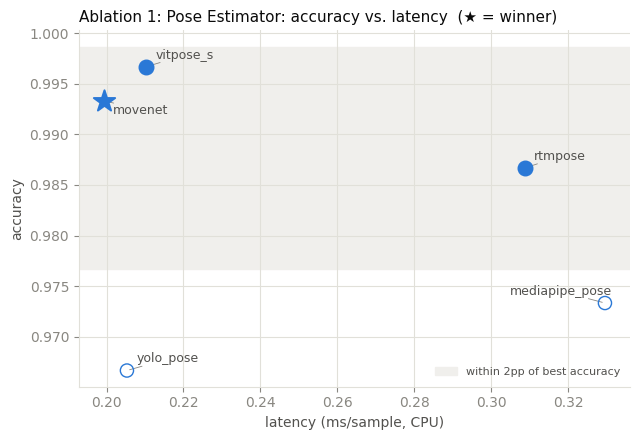

In [58]:
available_backends = [name for name, fn in POSE_BACKENDS.items() if fn is not None]
print(f"Running pose-estimator ablation over: {available_backends}")

pose_ablation_rows = []
for backend_name in available_backends:
    row = evaluate_arm(backend_name, "raw2d", "all", "svm")
    pose_ablation_rows.append(row)
    print(f"{backend_name}: acc={row['accuracy']:.3f} f1={row['f1']:.3f} "
          f"latency={row['latency_ms']:.2f}ms coverage={row['coverage_pct']:.0f}%")

pose_ablation_results = pd.DataFrame(pose_ablation_rows)
print("\n", pose_ablation_results[["pose_backend", "accuracy", "f1", "latency_ms", "coverage_pct"]])

BEST_POSE_BACKEND = pick_best(pose_ablation_results, "pose_backend")
plot_ablation_tradeoff(pose_ablation_results, "pose_backend", BEST_POSE_BACKEND, "Ablation 1: Pose Estimator")

## Ablation 2: Keypoint Representation

Fixed: pose_backend=`BEST_POSE_BACKEND`, selection=all, classifier=svm.

raw2d: acc=0.993 f1=0.993 latency=0.20ms
normalized: acc=0.983 f1=0.984 latency=0.22ms
relative: acc=0.977 f1=0.977 latency=0.22ms
bone_vectors: acc=0.990 f1=0.990 latency=0.21ms
angles: acc=0.977 f1=0.977 latency=0.19ms

   representation  accuracy        f1  latency_ms
0          raw2d  0.993333  0.993464    0.199745
1     normalized  0.983333  0.983923    0.216803
2       relative  0.976667  0.977492    0.221522
3   bone_vectors  0.990000  0.990228    0.211988
4         angles  0.976667  0.977346    0.194066
  shortlist (5/5 within 2.0pp of best accuracy 0.993): ['raw2d', 'normalized', 'relative', 'bone_vectors', 'angles']
  winner: angles (accuracy=0.977, latency=0.19ms)


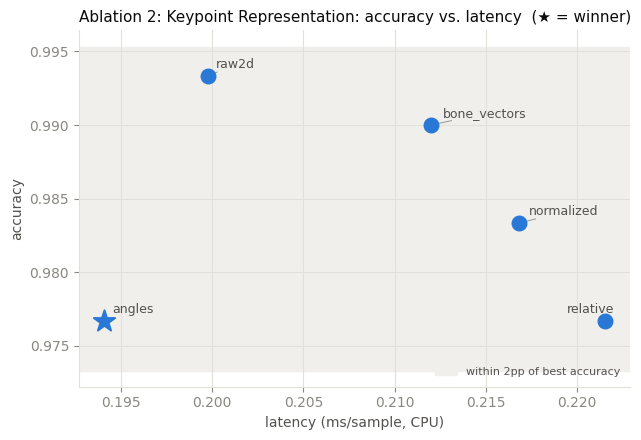

In [59]:
repr_rows = [evaluate_arm(BEST_POSE_BACKEND, r, "all", "svm") for r in REPRESENTATIONS]
for row in repr_rows:
    print(f"{row['representation']}: acc={row['accuracy']:.3f} f1={row['f1']:.3f} latency={row['latency_ms']:.2f}ms")

representation_results = pd.DataFrame(repr_rows)
print("\n", representation_results[["representation", "accuracy", "f1", "latency_ms"]])
BEST_REPRESENTATION = pick_best(representation_results, "representation")
plot_ablation_tradeoff(representation_results, "representation", BEST_REPRESENTATION, "Ablation 2: Keypoint Representation")

## Ablation 3: Feature Selection

Fixed: pose_backend=`BEST_POSE_BACKEND`, representation=`BEST_REPRESENTATION`, classifier=svm.
PCA is fit on the training split only (95% variance retained), so this
isolates the effect of dimensionality reduction, not information leakage.

all: acc=0.977 f1=0.977 latency=0.33ms
pca: acc=0.983 f1=0.984 latency=0.39ms

   selection  accuracy        f1  latency_ms
0       all  0.976667  0.977346    0.334186
1       pca  0.983333  0.983923    0.393008
  shortlist (2/2 within 2.0pp of best accuracy 0.983): ['all', 'pca']
  winner: all (accuracy=0.977, latency=0.33ms)


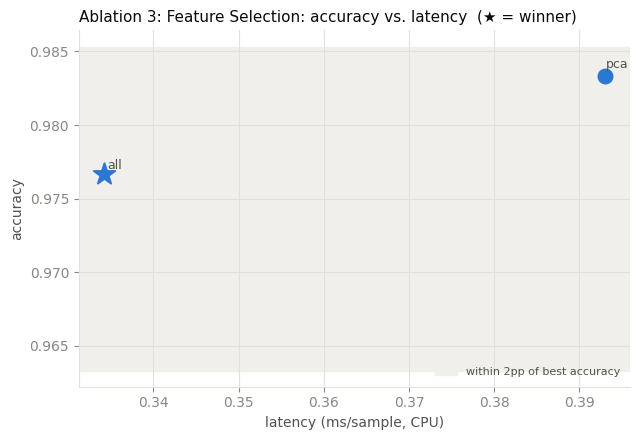

In [60]:
selection_rows = [evaluate_arm(BEST_POSE_BACKEND, BEST_REPRESENTATION, s, "svm") for s in ["all", "pca"]]
for row in selection_rows:
    print(f"{row['selection']}: acc={row['accuracy']:.3f} f1={row['f1']:.3f} latency={row['latency_ms']:.2f}ms")

selection_results = pd.DataFrame(selection_rows)
print("\n", selection_results[["selection", "accuracy", "f1", "latency_ms"]])
BEST_SELECTION = pick_best(selection_results, "selection")
plot_ablation_tradeoff(selection_results, "selection", BEST_SELECTION, "Ablation 3: Feature Selection")

## Ablation 4: Posture Classifier

Fixed: pose_backend=`BEST_POSE_BACKEND`, representation=`BEST_REPRESENTATION`, selection=`BEST_SELECTION`.

svm: acc=0.977 f1=0.977 latency=0.37ms
xgboost: acc=0.983 f1=0.984 latency=0.85ms
lightgbm: acc=0.987 f1=0.987 latency=1.76ms
1d_cnn: acc=0.777 f1=0.817 latency=1.47ms

   classifier  accuracy        f1  latency_ms
0        svm  0.976667  0.977346    0.365056
1    xgboost  0.983333  0.983923    0.845140
2   lightgbm  0.986667  0.987097    1.762458
3     1d_cnn  0.776667  0.817439    1.469770
  shortlist (3/4 within 2.0pp of best accuracy 0.987): ['svm', 'xgboost', 'lightgbm']
  winner: svm (accuracy=0.977, latency=0.37ms)


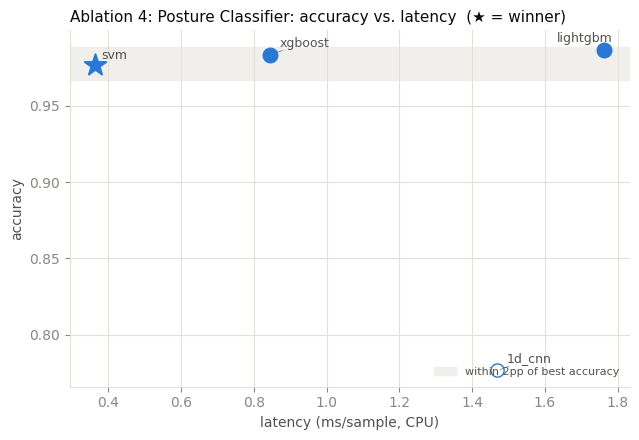

In [61]:
classifier_rows = [evaluate_arm(BEST_POSE_BACKEND, BEST_REPRESENTATION, BEST_SELECTION, c) for c in CLASSIFIERS]
for row in classifier_rows:
    print(f"{row['classifier']}: acc={row['accuracy']:.3f} f1={row['f1']:.3f} latency={row['latency_ms']:.2f}ms")

classifier_results = pd.DataFrame(classifier_rows)
print("\n", classifier_results[["classifier", "accuracy", "f1", "latency_ms"]])
BEST_CLASSIFIER = pick_best(classifier_results, "classifier")
plot_ablation_tradeoff(classifier_results, "classifier", BEST_CLASSIFIER, "Ablation 4: Posture Classifier")

## Final pipeline

In [62]:
print("Winning pipeline:")
print(f"  pose estimator:  {BEST_POSE_BACKEND}")
print(f"  representation:  {BEST_REPRESENTATION}")
print(f"  feature selection: {BEST_SELECTION}")
print(f"  classifier:      {BEST_CLASSIFIER}")
final = evaluate_arm(BEST_POSE_BACKEND, BEST_REPRESENTATION, BEST_SELECTION, BEST_CLASSIFIER)
print(f"  held-out test: accuracy={final['accuracy']:.3f} f1={final['f1']:.3f} latency={final['latency_ms']:.2f}ms")

Winning pipeline:
  pose estimator:  movenet
  representation:  angles
  feature selection: all
  classifier:      svm
  held-out test: accuracy=0.977 f1=0.977 latency=0.49ms


## Export the winning pipeline

Refits the winning (pose backend, representation, selection,
classifier) combination on train+val one more time -- this time keeping
every artifact needed to reproduce inference elsewhere: the imputation
means, the PCA transform (if selected), and the trained classifier
itself, exported to ONNX so it doesn't need this notebook's Python
environment to run. Matches this project's existing ONNX +
`*_meta.json` convention (see `slouchfix/models/export_onnx.py` /
`inference.py`) so the app side can load it the same way.

Each classifier family needs a different ONNX converter -- there's no
single "convert model to ONNX" call that covers sklearn's SVC,
XGBoost, LightGBM, and a raw PyTorch module.

In [63]:
%pip install -q onnxmltools skl2onnx

In [64]:
import os

EXPORT_DIR = "posture_pipeline_export"
os.makedirs(EXPORT_DIR, exist_ok=True)


def export_winning_pipeline() -> None:
    cache = get_pose_cache(BEST_POSE_BACKEND)
    x_all = build_feature_matrix(cache["keypoints"], BEST_REPRESENTATION)
    x_train, x_val = x_all[TRAIN_IDX], x_all[VAL_IDX]
    y_fit = np.concatenate([y[TRAIN_IDX], y[VAL_IDX]])

    col_mean = np.nanmean(x_train, axis=0)
    col_mean = np.where(np.isnan(col_mean), 0.0, col_mean)
    x_train_imputed, x_val_imputed = mean_impute(x_train, x_val)
    x_fit = np.concatenate([x_train_imputed, x_val_imputed], axis=0)

    pca_obj, scaler_obj = None, None
    if BEST_SELECTION == "pca":
        from sklearn.decomposition import PCA
        from sklearn.preprocessing import StandardScaler

        scaler_obj = StandardScaler().fit(x_fit)
        pca_obj = PCA(n_components=0.95, svd_solver="full", random_state=RANDOM_SEED).fit(scaler_obj.transform(x_fit))
        x_fit = pca_obj.transform(scaler_obj.transform(x_fit))

    model = CLASSIFIERS[BEST_CLASSIFIER]().fit(x_fit, y_fit)
    n_features = x_fit.shape[1]

    onnx_path = os.path.join(EXPORT_DIR, "posture_pipeline.onnx")
    if BEST_CLASSIFIER == "svm":
        from skl2onnx import convert_sklearn
        from skl2onnx.common.data_types import FloatTensorType

        onnx_model = convert_sklearn(model, initial_types=[("input", FloatTensorType([None, n_features]))])
        with open(onnx_path, "wb") as fh:
            fh.write(onnx_model.SerializeToString())
    elif BEST_CLASSIFIER == "xgboost":
        from onnxmltools import convert_xgboost
        from onnxmltools.convert.common.data_types import FloatTensorType as OMFloatTensorType

        onnx_model = convert_xgboost(model, initial_types=[("input", OMFloatTensorType([None, n_features]))])
        with open(onnx_path, "wb") as fh:
            fh.write(onnx_model.SerializeToString())
    elif BEST_CLASSIFIER == "lightgbm":
        from onnxmltools import convert_lightgbm
        from onnxmltools.convert.common.data_types import FloatTensorType as OMFloatTensorType

        onnx_model = convert_lightgbm(model, initial_types=[("input", OMFloatTensorType([None, n_features]))])
        with open(onnx_path, "wb") as fh:
            fh.write(onnx_model.SerializeToString())
    elif BEST_CLASSIFIER == "1d_cnn":
        import torch

        dummy = torch.zeros(1, 1, n_features, dtype=torch.float32)
        torch.onnx.export(
            model._model, dummy, onnx_path,
            input_names=["input"], output_names=["logits"],
            dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
        )
    else:
        raise ValueError(BEST_CLASSIFIER)

    meta = {
        "pose_backend": BEST_POSE_BACKEND,
        "representation": BEST_REPRESENTATION,
        "selection": BEST_SELECTION,
        "classifier": BEST_CLASSIFIER,
        "labels": ["good", "slouched"],
        "n_features": n_features,
        "impute_mean": col_mean.tolist(),
        "cnn_input_standardize": {"mean": model._mean.tolist(), "std": model._std.tolist()} if BEST_CLASSIFIER == "1d_cnn" else None,
        "pca_mean": (scaler_obj.mean_.tolist() if scaler_obj is not None else None),
        "pca_scale": (scaler_obj.scale_.tolist() if scaler_obj is not None else None),
        "pca_components": (pca_obj.components_.tolist() if pca_obj is not None else None),
    }
    meta_path = os.path.join(EXPORT_DIR, "posture_pipeline_meta.json")
    with open(meta_path, "w") as fh:
        json.dump(meta, fh, indent=2)

    print(f"Exported {onnx_path} and {meta_path}")


export_winning_pipeline()

Exported posture_pipeline_export/posture_pipeline.onnx and posture_pipeline_export/posture_pipeline_meta.json
